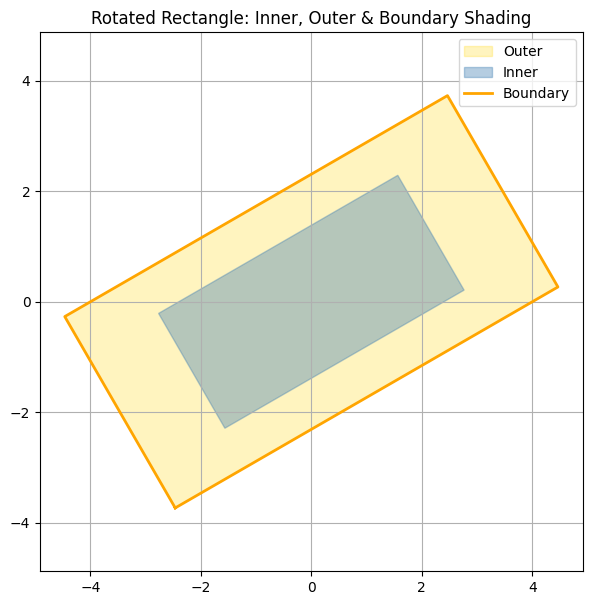

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parameters
# -------------------------
a, b = 0, 0                 # center of rectangle
theta = np.deg2rad(30)      # rotation angle

# Outer rectangle half-widths
w_outer, h_outer = 4, 2

# Inner rectangle half-widths
w_inner, h_inner = 2.5, 1.2

# -------------------------
# Helper functions
# -------------------------

def rectangle_corners(w, h):
    """Return the 4 corners of an axis-aligned rectangle centered at origin."""
    return np.array([
        [-w, -h],
        [ w, -h],
        [ w,  h],
        [-w,  h]
    ])

def rotate_points(points, theta):
    """Rotate Nx2 points by angle theta around origin."""
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    return points @ R.T

# -------------------------
# Compute rectangles
# -------------------------

outer_local = rectangle_corners(w_outer, h_outer)
inner_local = rectangle_corners(w_inner, h_inner)

outer_global = rotate_points(outer_local, theta) + np.array([a, b])
inner_global = rotate_points(inner_local, theta) + np.array([a, b])

# -------------------------
# Plot rectangles
# -------------------------

plt.figure(figsize=(7,7))

# Outer shaded region
plt.fill(outer_global[:,0], outer_global[:,1], color='gold', alpha=0.25, label="Outer")

# Inner shaded region
plt.fill(inner_global[:,0], inner_global[:,1], color='steelblue', alpha=0.4, label="Inner")

# Draw outer boundary
outer_closed = np.vstack([outer_global, outer_global[0]])
plt.plot(outer_closed[:,0], outer_closed[:,1], color='orange', linewidth=2, label="Boundary")

plt.axis('equal')
plt.title("Rotated Rectangle: Inner, Outer & Boundary Shading")
plt.legend()
plt.grid(True)
plt.show()


In [52]:
th = 0
w = 30
h = 60
a = 0
b = 0
x = 30
y = 60
axy = (np.cos(th) * (x-a) + np.sin(th) * (y-b))**2 - w**2
bxy = (-np.sin(th) * (x-a) + np.cos(th) * (y-b))**2 - h**2
grad_axy = np.array([
    [2*np.cos(th)*(np.cos(th)*(x-a) + np.sin(th)*(y-b)),
    2*np.sin(th)*(np.cos(th)*(x-a) + np.sin(th)*(y-b))]
])
grad_bxy = np.array([
    [-2*np.sin(th)*(-np.sin(th) * (x-a) + np.cos(th) * (y-b)),
    2*np.cos(th)*(-np.sin(th) * (x-a) + np.cos(th) * (y-b))]
])

gamma = 0.001
ab_arr = np.array([axy, bxy])
ab_max = np.max(ab_arr)
ab_shift = ab_arr - ab_max
ab_exp = np.exp(gamma*ab_shift)
sum_ab_exp = np.sum(ab_exp)
p_ab = ab_exp / sum_ab_exp
hxy = 1/gamma * np.log(sum_ab_exp) + ab_arr_max
grad_hxy = p_ab[0] * grad_axy + p_ab[1] * grad_bxy
print(hxy)
print(p_ab)
print(grad_axy, grad_bxy)
print(grad_hxy)

693.1471805599452
[0.5 0.5]
[[60.  0.]] [[ -0. 120.]]
[[30. 60.]]


In [8]:
import numpy as np

a = np.array([
    [1,2,3], [3,4,5], [4,5,6]
])

b = np.array([
    [3,4,1], [2,7,1], [4,5,6]
])

ab = np.concatenate((np.array([a]),np.array([b])))
ab_max = np.max(ab, axis=0)
ab_shift = ab - ab_max
exp_ab = np.exp(1 * ab_shift)
sum_exp_ab = np.sum(exp_ab, axis=0)
p_ab = exp_ab / (sum_exp_ab)
p_ab[0]

array([[0.11920292, 0.11920292, 0.88079708],
       [0.73105858, 0.04742587, 0.98201379],
       [0.5       , 0.5       , 0.5       ]])